Alexander W. Criswell 2/9/26

Notebook to test eccentricity grids using legwork.

In [1]:
import numpy as np
from legwork import evol, utils
import astropy.units as u
from WaveformTools import Binary
import matplotlib.pyplot as plt

Below is from the legwork tutorials

In [2]:
# pick some values
ecc_i = 0.1
m_1 = 1e9 * u.Msun
m_2 = 1e9 * u.Msun
f_orb_i = 1e-8 * u.Hz

# calculate other params
beta = utils.beta(m_1=m_1, m_2=m_2)
a_i = utils.get_a_from_f_orb(f_orb=f_orb_i, m_1=m_1, m_2=m_2)

# compute with individual masses and frequency
t_merge = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=f_orb_i)

# compute with beta and semi-major axis
t_merge_alt = evol.get_t_merge_ecc(ecc_i=ecc_i, beta=beta, a_i=a_i)

# check you get the same result
print(t_merge == t_merge_alt)

True


In [3]:
t_merge.to(u.yr)

<Quantity 8368.92978096 yr>

In [4]:
tsteps = evol.evol_ecc(ecc_i, m_1=m_1, m_2=m_2, f_orb_i=f_orb_i,t_before=10*u.yr,
                       output_vars=["timesteps"])

In [5]:
tsteps

<Quantity [   0.        ,   84.53464425,  169.0692885 ,  253.60393276,
            338.13857701,  422.67322126,  507.20786551,  591.74250976,
            676.27715402,  760.81179827,  845.34644252,  929.88108677,
           1014.41573103, 1098.95037528, 1183.48501953, 1268.01966378,
           1352.55430803, 1437.08895229, 1521.62359654, 1606.15824079,
           1690.69288504, 1775.22752929, 1859.76217355, 1944.2968178 ,
           2028.83146205, 2113.3661063 , 2197.90075055, 2282.43539481,
           2366.97003906, 2451.50468331, 2536.03932756, 2620.57397182,
           2705.10861607, 2789.64326032, 2874.17790457, 2958.71254882,
           3043.24719308, 3127.78183733, 3212.31648158, 3296.85112583,
           3381.38577008, 3465.92041434, 3550.45505859, 3634.98970284,
           3719.52434709, 3804.05899135, 3888.5936356 , 3973.12827985,
           4057.6629241 , 4142.19756835, 4226.73221261, 4311.26685686,
           4395.80150111, 4480.33614536, 4564.87078961, 4649.40543387,
      

Okay so t=0 is a random shared reference point. That's really annoying. Let's see if we can work aroun that. What we will eventually want is to know the state of the binary at a known series of times *before* merger.

So we need to do a two-step process?

In [6]:
tsteps, fgws, ecc, a = evol.evol_ecc(0.2, m_1=m_1, m_2=m_2, f_orb_i=5e-9*u.Hz, t_before=10*u.yr,
                                       output_vars=["timesteps","f_GW","ecc","a"])

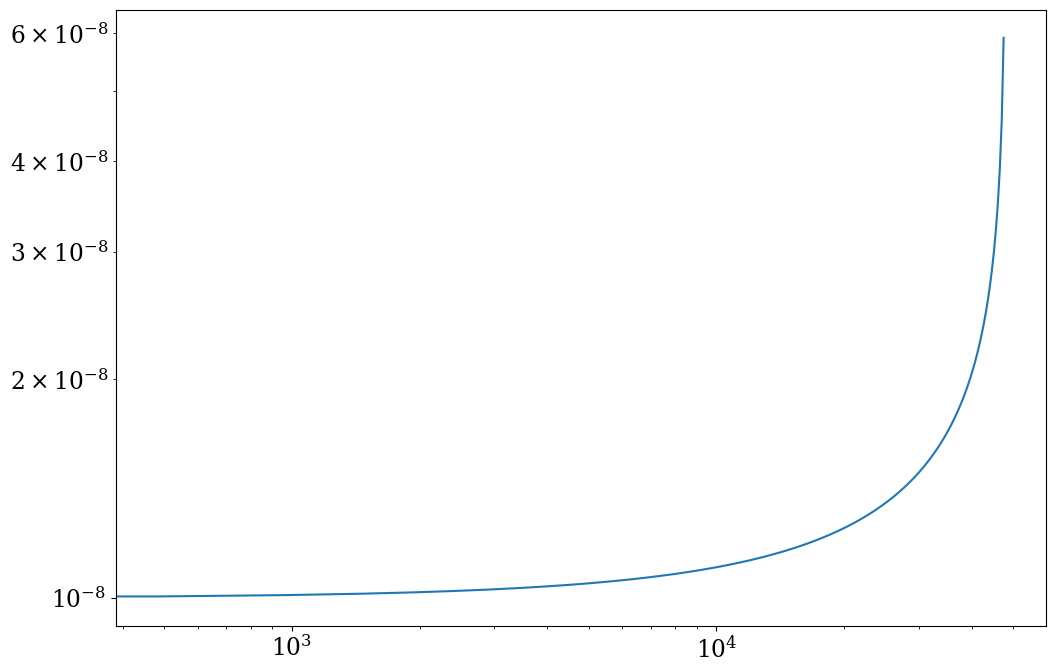

In [7]:
plt.figure()
plt.loglog(tsteps,fgws)
plt.show()

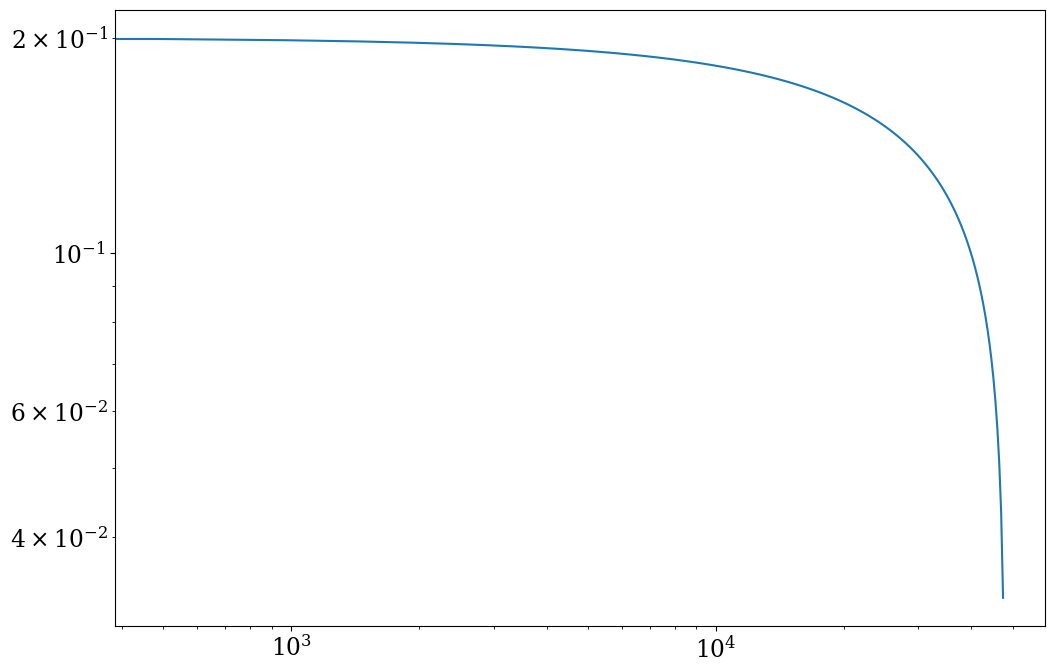

In [8]:
plt.figure()
plt.loglog(tsteps,ecc)
plt.show()

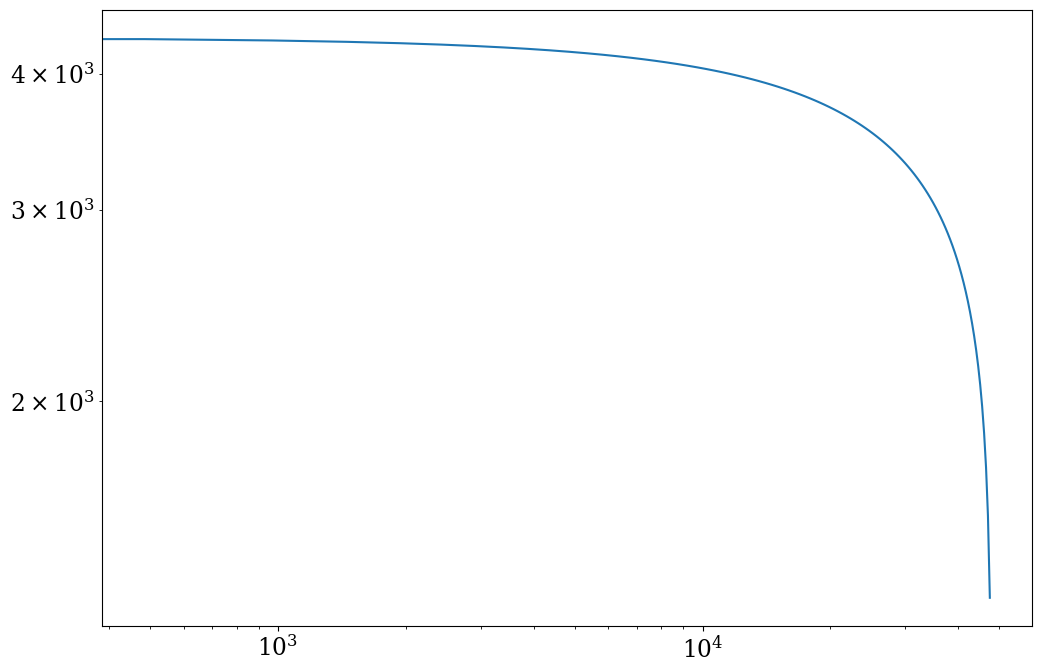

In [9]:
plt.figure()
plt.loglog(tsteps,a)
plt.show()

In [10]:
u.pc.to(u.AU)

206264.80624709636

In [11]:
tsteps, fgws, ecc, a = evol.evol_ecc(0.2, m_1=m_1, m_2=m_2, a_i=0.05*u.pc, t_before=10*u.yr,
                                       output_vars=["timesteps","f_GW","ecc","a"])

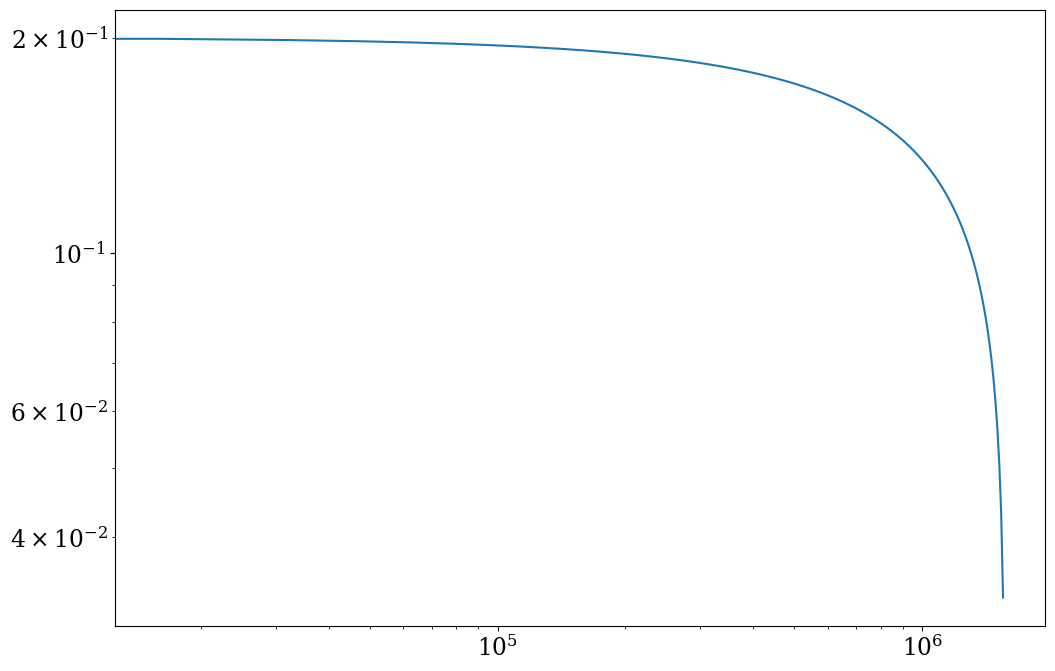

In [12]:
plt.figure()
plt.loglog(tsteps,ecc)
plt.show()

In [13]:
pulsar_times = [100,500,1000,2000,3000,5000,8000,9000,10000,15000]*u.yr

In [14]:
## part 1: get time to merger
ecc0 = 0.85
forb0 = 1e-9 * u.Hz
t_merger = evol.get_t_merge_ecc(ecc_i=ecc0, m_1=m_1, m_2=m_2, f_orb_i=forb0)
print(t_merger)

4.9298610982695225e-05 Gyr


In [15]:
t_merger.to(u.yr)

<Quantity 49298.6109827 yr>

In [16]:
tarrnz = t_merger.to(u.yr)-pulsar_times[::-1]
tarr = np.array([0.,*tarrnz.value])*u.yr
tarr

<Quantity [    0.       , 34298.6109827, 39298.6109827, 40298.6109827,
           41298.6109827, 44298.6109827, 46298.6109827, 47298.6109827,
           48298.6109827, 48798.6109827, 49198.6109827] yr>

In [17]:
## part 2: calculate values for waveform as seen by pulsars
## by perfoming evolution evaluated at t_merger - pulsar_times
timesteps, fgws, ecc, a = evol.evol_ecc(ecc0,m_1=m_1, m_2=m_2, a_i=0.05*u.pc,n_step=2000,t_evol=t_merger-10*u.yr,t_before=10*u.yr,
                                           output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)

In [18]:
timesteps

<Quantity [    0.        ,    24.65663381,    49.31326762, ...,
           21993.71735696, 21993.71735696, 21993.71735696] yr>

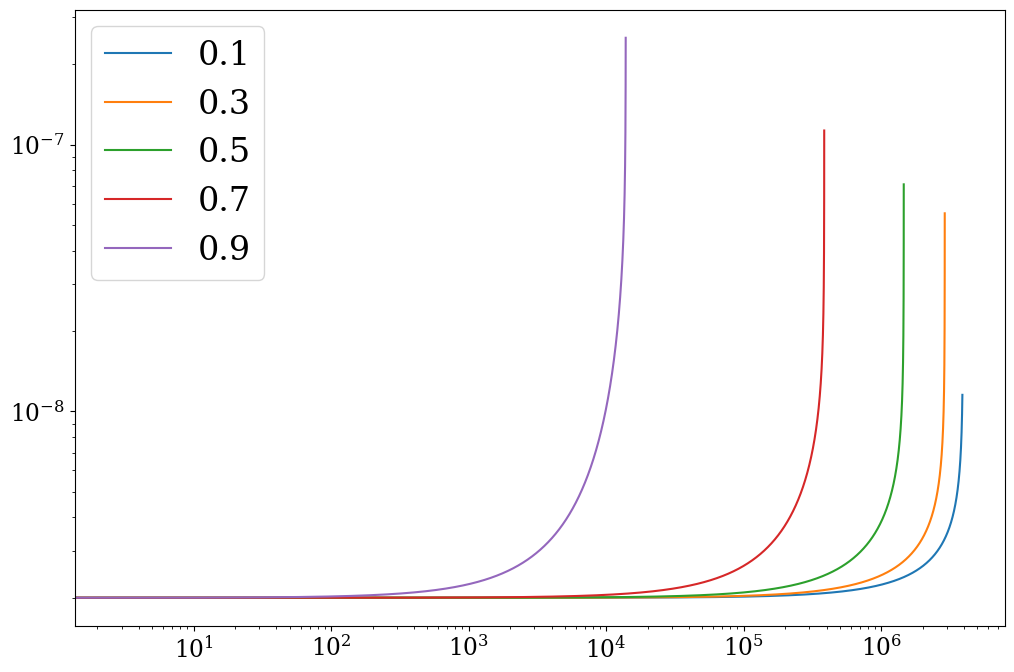

In [19]:
plt.figure()
for ecc_i in [0.1,0.3,0.5,0.7,0.9]:
    forb0 = 1e-9 * u.Hz
    t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0)
    timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=5000,t_evol=t_merger-10*u.yr,t_before=10*u.yr,
                                           output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
    plt.loglog(timesteps,fgws,label=str(ecc_i))
plt.legend()
plt.show()

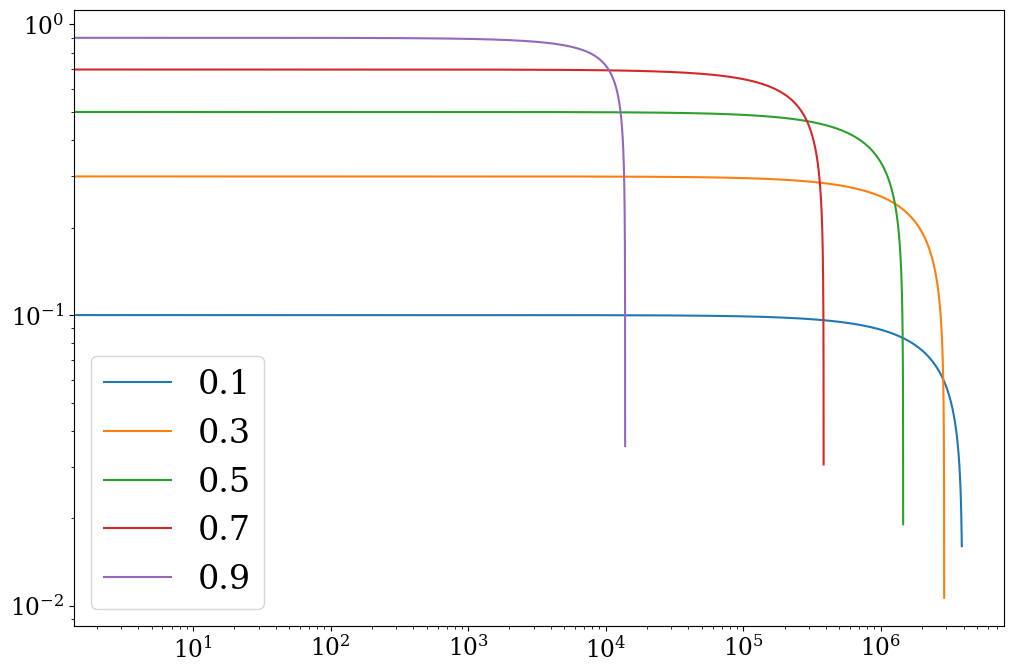

In [20]:
plt.figure()
for ecc_i in [0.1,0.3,0.5,0.7,0.9]:
    forb0 = 1e-9 * u.Hz
    t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0)
    timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=5000,t_evol=t_merger-1*u.yr,t_before=1*u.yr,
                                           output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
    plt.loglog(timesteps,ecc,label=str(ecc_i))
plt.legend()
plt.show()

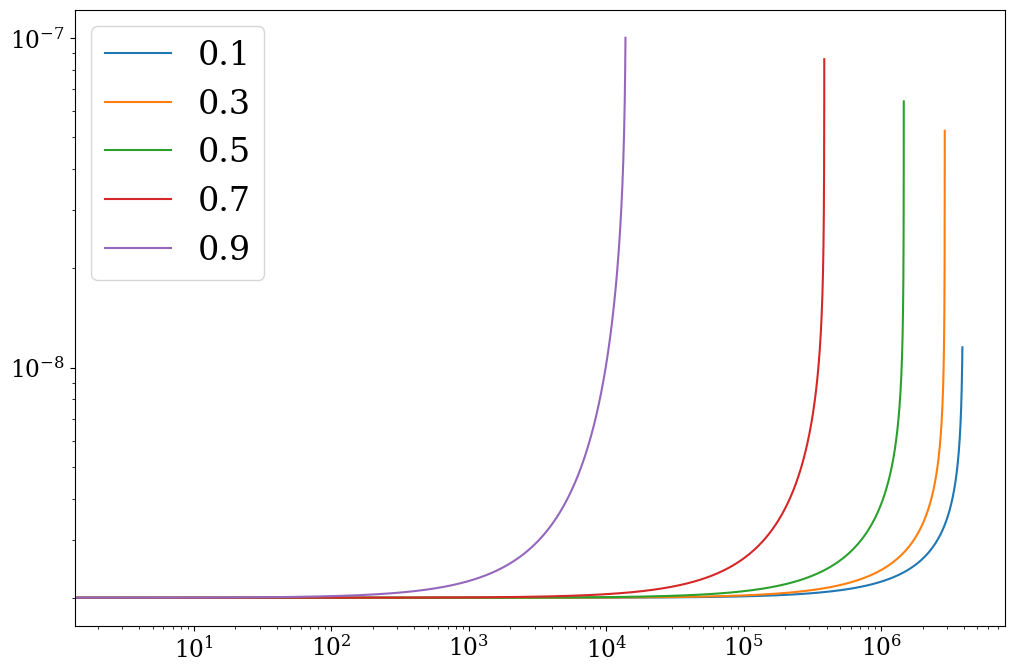

In [21]:
plt.figure()
merge_pad = 100*u.yr
for ecc_i in [0.1,0.3,0.5,0.7,0.9]:
    forb0 = 1e-9 * u.Hz
    t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True)
    timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=5000,
                                            t_evol=t_merger-merge_pad,t_before=merge_pad,
                                           output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
    plt.loglog(timesteps,fgws,label=str(ecc_i))
plt.legend()
plt.show()

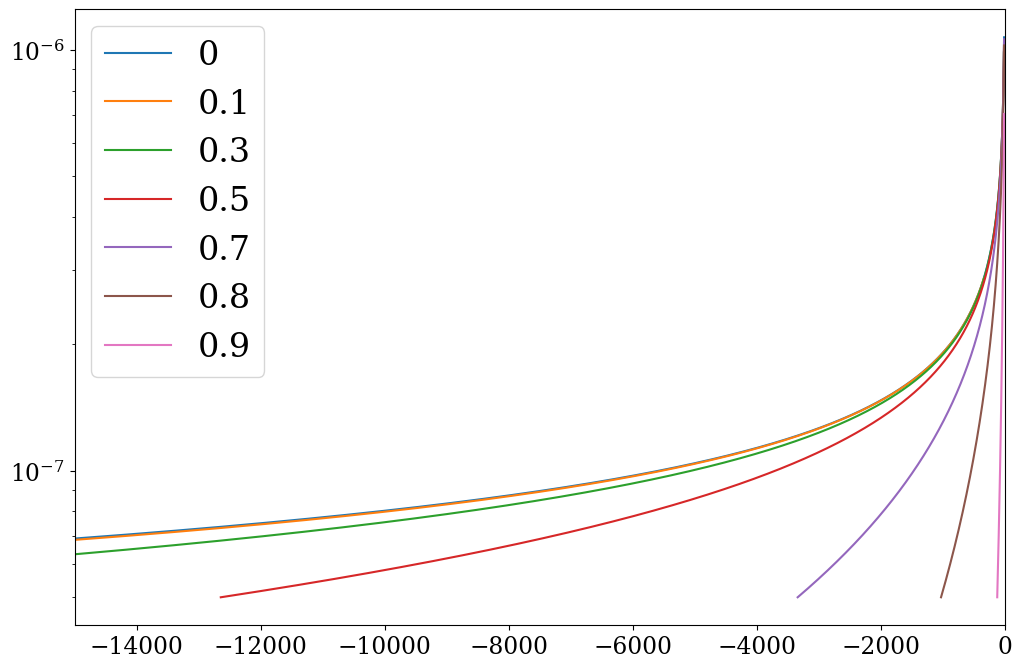

In [22]:
plt.figure()
merge_pad = 10*u.yr
m_1 = m_2 = 1e8*u.Msun
for ecc_i in [0,0.1,0.3,0.5,0.7,0.8,0.9]:
    fgw = 5e-8*u.Hz
    forb0 = fgw/2
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
    plt.plot(timesteps-t_merger,fgws,label=str(ecc_i))
plt.yscale('log')
plt.xlim(-15000,0)
plt.legend()
plt.show()

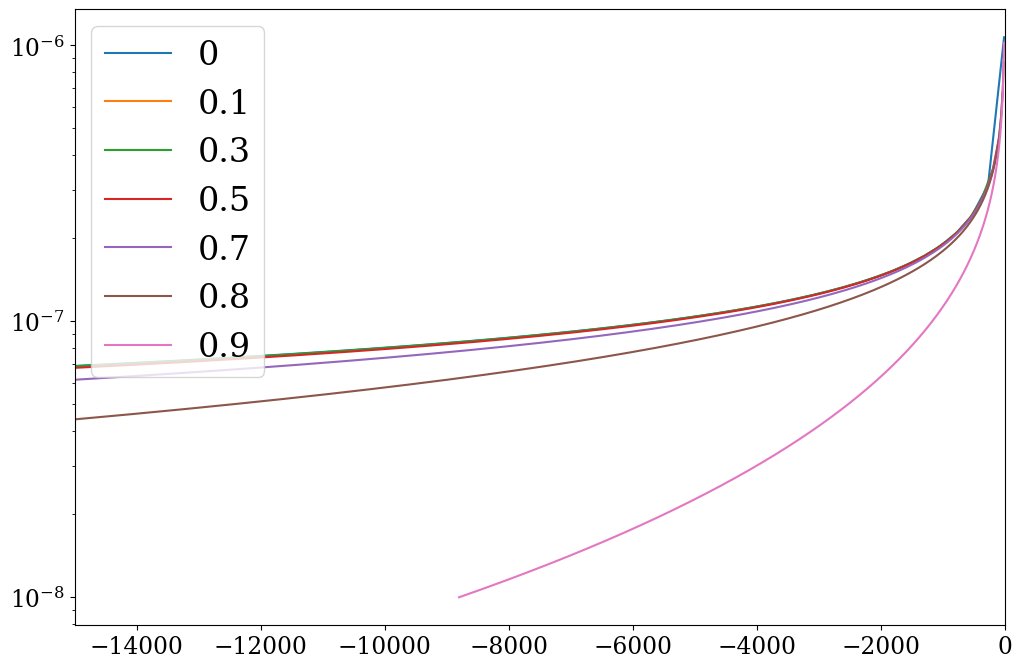

In [23]:
plt.figure()
merge_pad = 10*u.yr
m_1 = m_2 = 1e8*u.Msun
for ecc_i in [0,0.1,0.3,0.5,0.7,0.8,0.9]:
    fgw = 1e-8*u.Hz
    forb0 = fgw/2
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
    plt.plot(timesteps-t_merger,fgws,label=str(ecc_i))
plt.yscale('log')
plt.xlim(-15000,0)
plt.legend()
plt.show()

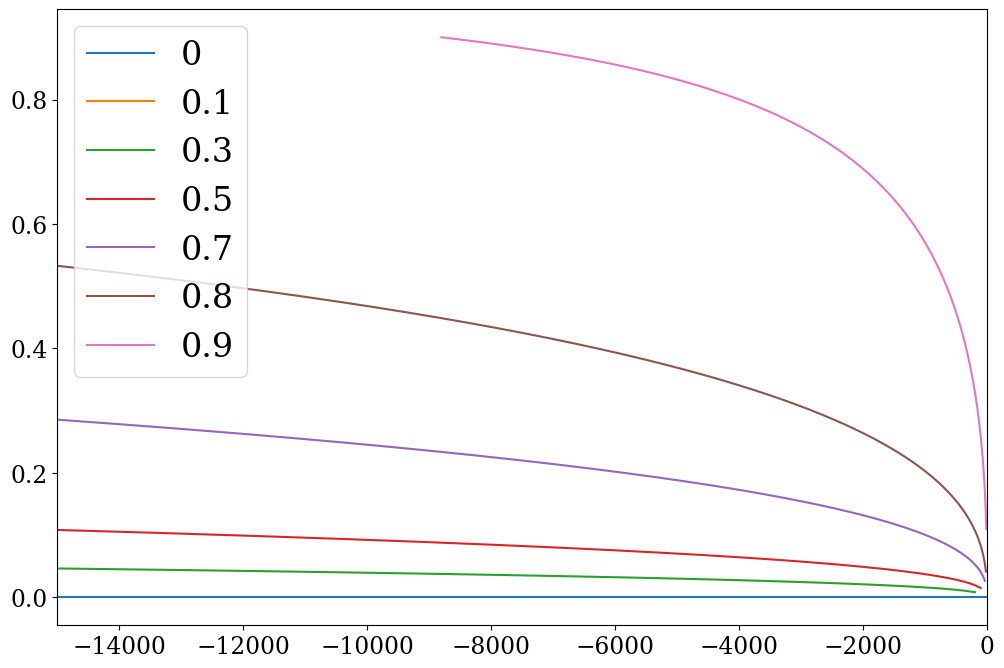

In [24]:
plt.figure()
merge_pad = 10*u.yr
m_1 = m_2 = 1e8*u.Msun
for ecc_i in [0,0.1,0.3,0.5,0.7,0.8,0.9]:
    fgw = 1e-8*u.Hz
    forb0 = fgw/2
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label=str(ecc_i))
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
        plt.plot(timesteps-t_merger,ecc,label=str(ecc_i))
# plt.yscale('log')
plt.xlim(-15000,0)
plt.legend()
plt.show()

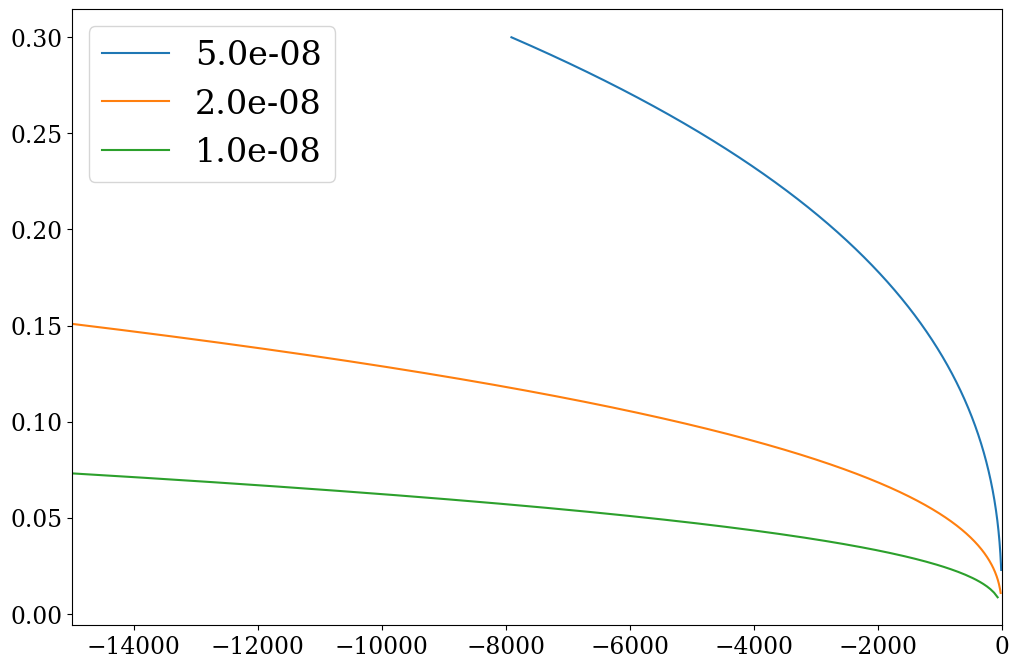

In [25]:
plt.figure()
merge_pad = 10*u.yr
m_1 = m_2 = 2e8*u.Msun
for f0 in [5e-8,2e-8,1e-8]:
    ecc_i = 0.3
    fgw = f0*u.Hz
    forb0 = fgw/2
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label="{:0.1e}".format(f0))
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
        plt.plot(timesteps-t_merger,ecc,label="{:0.1e}".format(f0))
# plt.yscale('log')
plt.xlim(-15000,0)
plt.legend(loc='upper left')
plt.show()

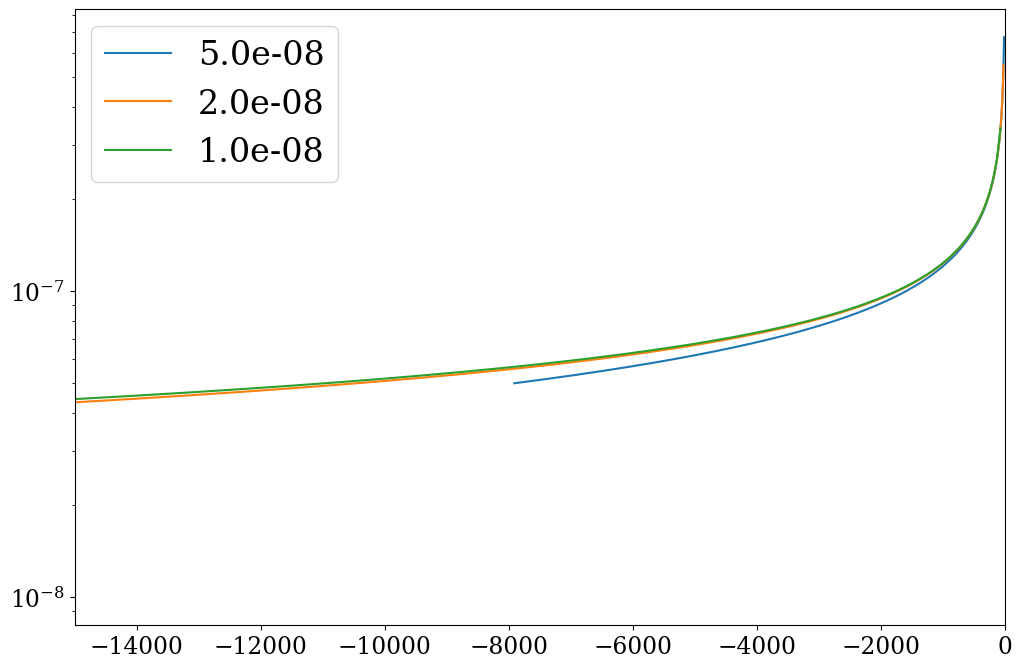

In [26]:
plt.figure()
merge_pad = 10*u.yr
m_1 = m_2 = 2e8*u.Msun
for f0 in [5e-8,2e-8,1e-8]:
    ecc_i = 0.3
    fgw = f0*u.Hz
    forb0 = fgw/2
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        # plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label="{:0.1e}".format(f0))
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
    plt.plot(timesteps-t_merger,fgws,label="{:0.1e}".format(f0))
plt.yscale('log')
plt.xlim(-15000,0)
plt.legend(loc='upper left')
plt.show()

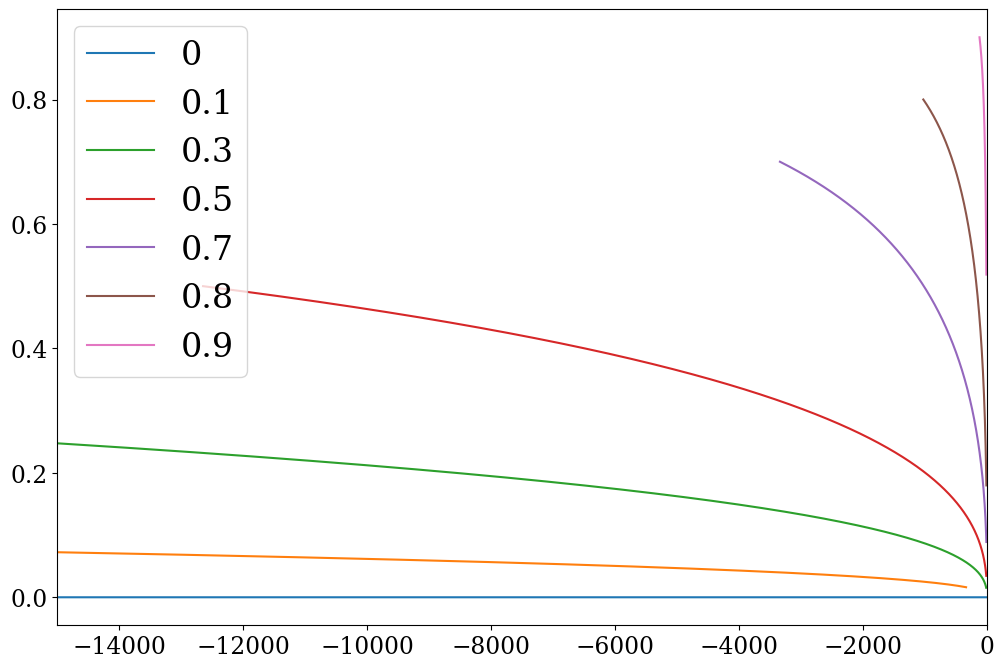

In [27]:
plt.figure()
merge_pad = 10*u.yr
m_1 = m_2 = 1e8*u.Msun
for ecc_i in [0,0.1,0.3,0.5,0.7,0.8,0.9]:
    fgw = 5e-8*u.Hz
    forb0 = fgw/2
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label=str(ecc_i))
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
        plt.plot(timesteps-t_merger,ecc,label=str(ecc_i))
# plt.yscale('log')
plt.xlim(-15000,0)
plt.legend()
plt.show()

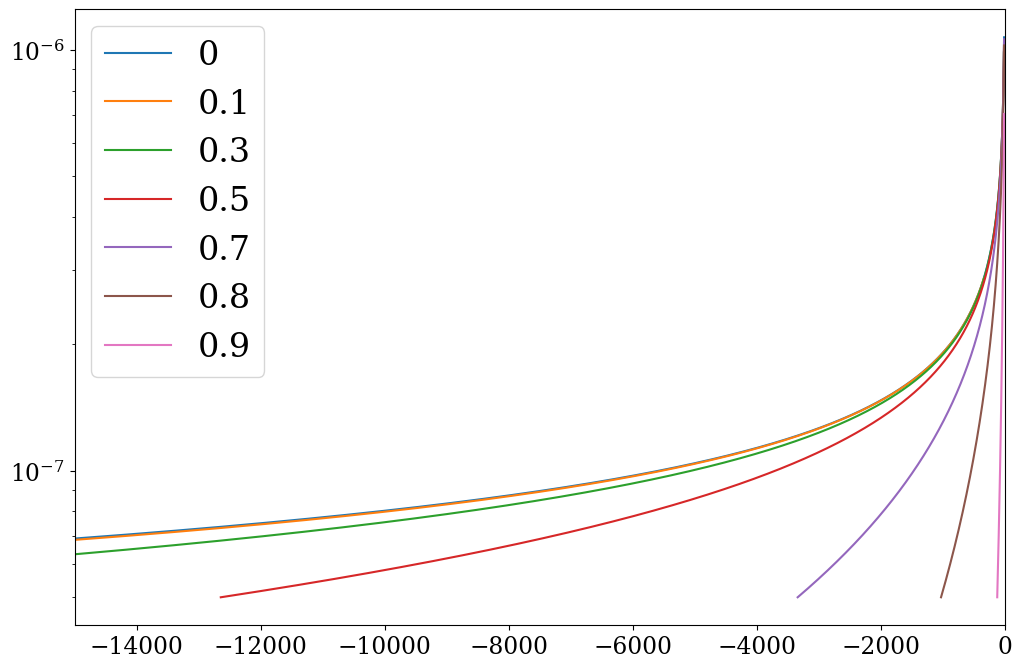

In [28]:
plt.figure()
merge_pad = 10*u.yr
m_1 = m_2 = 1e8*u.Msun
for ecc_i in [0,0.1,0.3,0.5,0.7,0.8,0.9]:
    fgw = 5e-8*u.Hz
    forb0 = fgw/2
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        # plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label=str(ecc_i))
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
    plt.plot(timesteps-t_merger,fgws,label=str(ecc_i))
plt.yscale('log')
plt.xlim(-15000,0)
plt.legend()
plt.show()

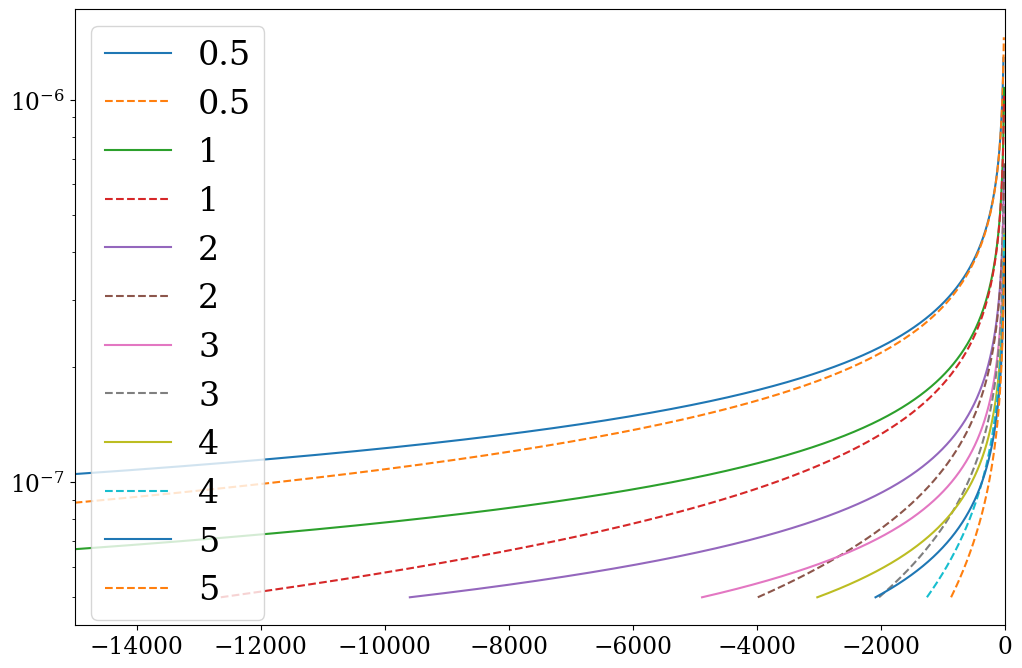

In [29]:
plt.figure()
merge_pad = 10*u.yr

for m in [0.5,1,2,3,4,5]:
    mark = False
    for ecc_i in [0.2,0.5]:
        fgw = 5e-8*u.Hz
        m_1 = m_2 = m*1e8*u.Msun
        forb0 = fgw/2
        if ecc_i == 0:
            t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
            timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                    t_evol=t_merger-merge_pad,
                                                   output_vars=["timesteps","f_GW","a"])
            # plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label=str(ecc_i))
        else:
            t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
            timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=10000,
                                                    t_evol=t_merger-merge_pad,t_before=merge_pad,
                                                   output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
        if mark:
            plt.plot(timesteps-t_merger,fgws,label=str(m),ls='--')
        else:
            plt.plot(timesteps-t_merger,fgws,label=str(m))
            mark = True
plt.yscale('log')
plt.xlim(-15000,0)
plt.legend()
plt.show()

21731.207911422483 yr
 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.1099380084430D+16   r2 =                  NaN


/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


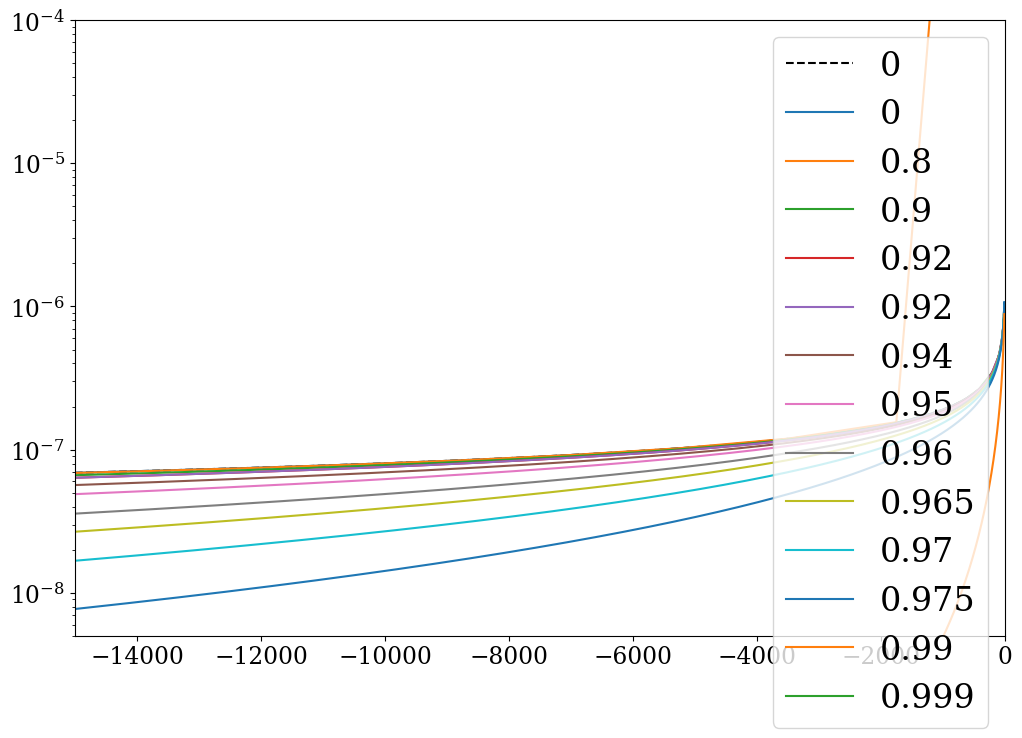

In [42]:
plt.figure()
merge_pad = 10*u.yr
m_1 = m_2 = 1e8*u.Msun
for ecc_i in [0,0.8,0.9,0.92,0.92,0.94,0.95,0.96,0.965,0.97,0.975,0.99,0.999]:
    fgw = 1e-9*u.Hz
    forb0 = fgw/2
    if ecc_i == 0:
        ecc0_f0 = 3e-8*u.Hz
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=ecc0_f0)
        print(t_merger.to(u.yr))
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=ecc0_f0,n_step=20000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        # plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label=str(ecc_i))
        plt.plot(timesteps-t_merger,fgws,label=str(ecc_i),c='k',ls='--')
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=20000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
    plt.plot(timesteps-t_merger,fgws,label=str(ecc_i))
plt.yscale('log')
plt.xlim(-15000,0)
plt.ylim(5e-9,1e-4)
plt.legend(loc='upper right')
plt.show()

21731.207911422483 yr
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380482283D+16   r2 =  0.2471145149450D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380482283D+16   r2 =  0.2471145149450D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380482283D+16   r2 =  0.2471145149450D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380482283D+16   r2 =  0.3293230604906D-01
 lsoda--  warn

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


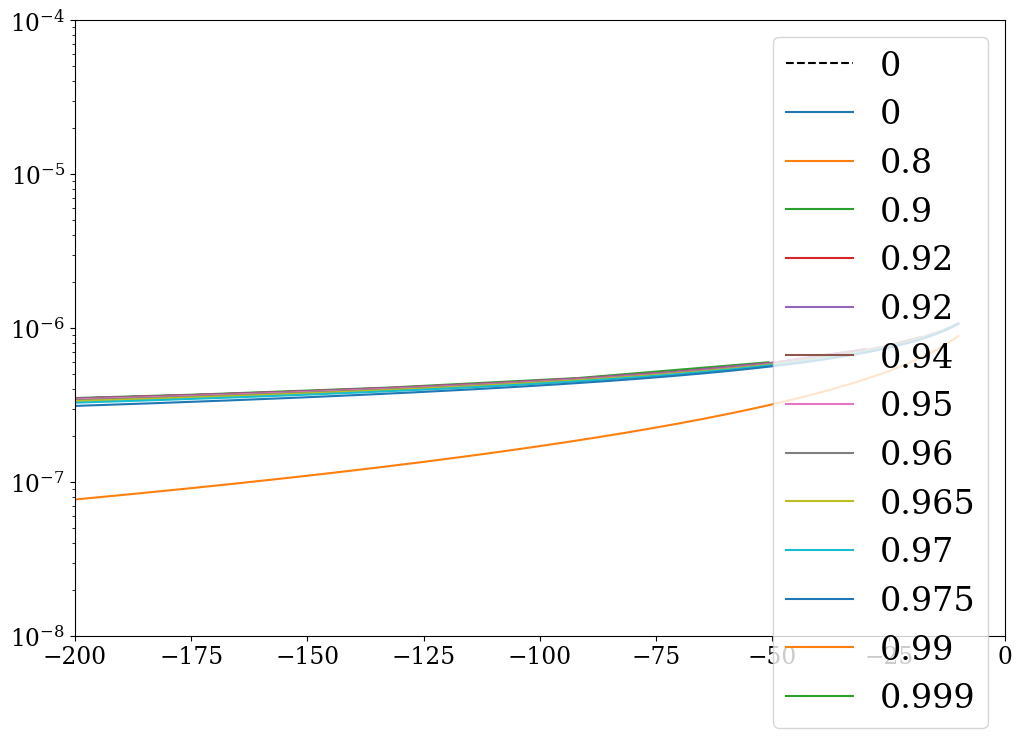

In [39]:
plt.figure()
merge_pad = 10*u.yr
m_1 = m_2 = 1e8*u.Msun
for ecc_i in [0,0.8,0.9,0.92,0.92,0.94,0.95,0.96,0.965,0.97,0.975,0.99,0.999]:
    fgw = 1e-9*u.Hz
    forb0 = fgw/2
    if ecc_i == 0:
        ecc0_f0 = 3e-8*u.Hz
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=ecc0_f0)
        print(t_merger.to(u.yr))
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=ecc0_f0,n_step=100000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        # plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label=str(ecc_i))
        plt.plot(timesteps-t_merger,fgws,label=str(ecc_i),c='k',ls='--')
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=100000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
    plt.plot(timesteps-t_merger,fgws,label=str(ecc_i))
plt.yscale('log')
plt.xlim(-200,0)
plt.ylim(1e-8,1e-4)
plt.legend()
plt.show()

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380540552D+16   r2 =  0.2358735426051D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380540552D+16   r2 =  0.2358735426051D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380540552D+16   r2 =  0.2052052364234D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380540552D+16   r2 =  0.5130130910584D-02
 lsoda--  warning..internal t (=r1) 

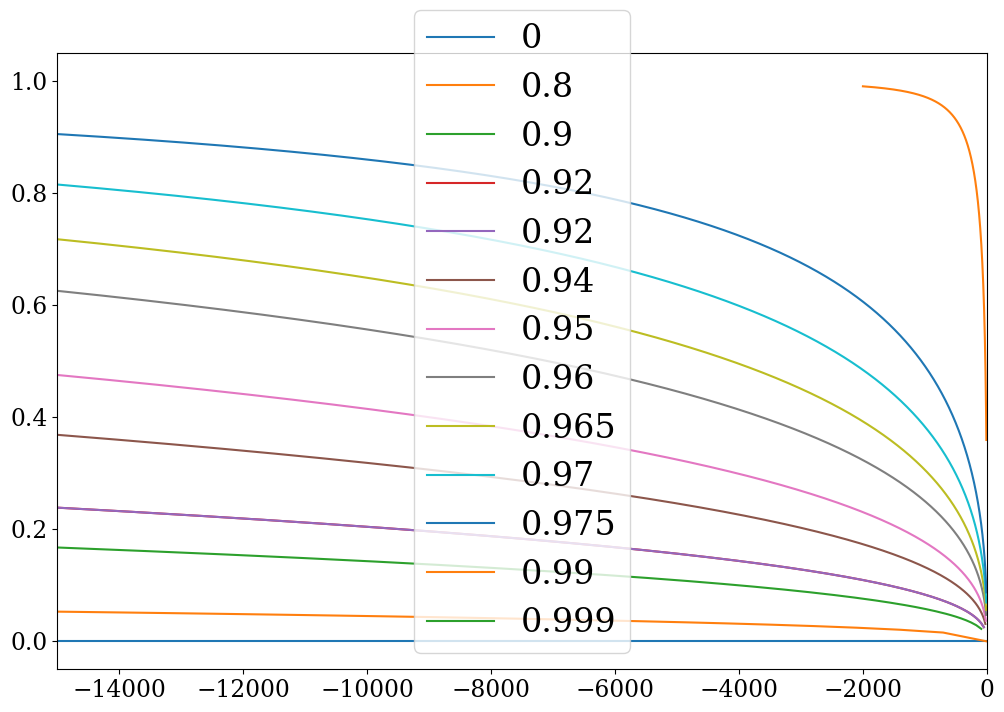

In [40]:
plt.figure()
merge_pad = 10*u.yr
m_1 = m_2 = 1e8*u.Msun
for ecc_i in [0,0.8,0.9,0.92,0.92,0.94,0.95,0.96,0.965,0.97,0.975,0.99,0.999]:
    fgw = 1e-9*u.Hz
    forb0 = fgw/2
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=50000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label=str(ecc_i))
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=50000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
        plt.plot(timesteps-t_merger,ecc,label=str(ecc_i))
# plt.yscale('log')
plt.xlim(-15000,0)
# plt.xlim(-200,0)
# plt.ylim(1e-8,1e-6)
plt.legend()
plt.show()

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380482279D+16   r2 =  0.2471721431169D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380482279D+16   r2 =  0.2471721431169D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380482279D+16   r2 =  0.2471721431169D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1099380482279D+16   r2 =  0.3294121058394D-01
 lsoda--  warning..internal t (=r1) 

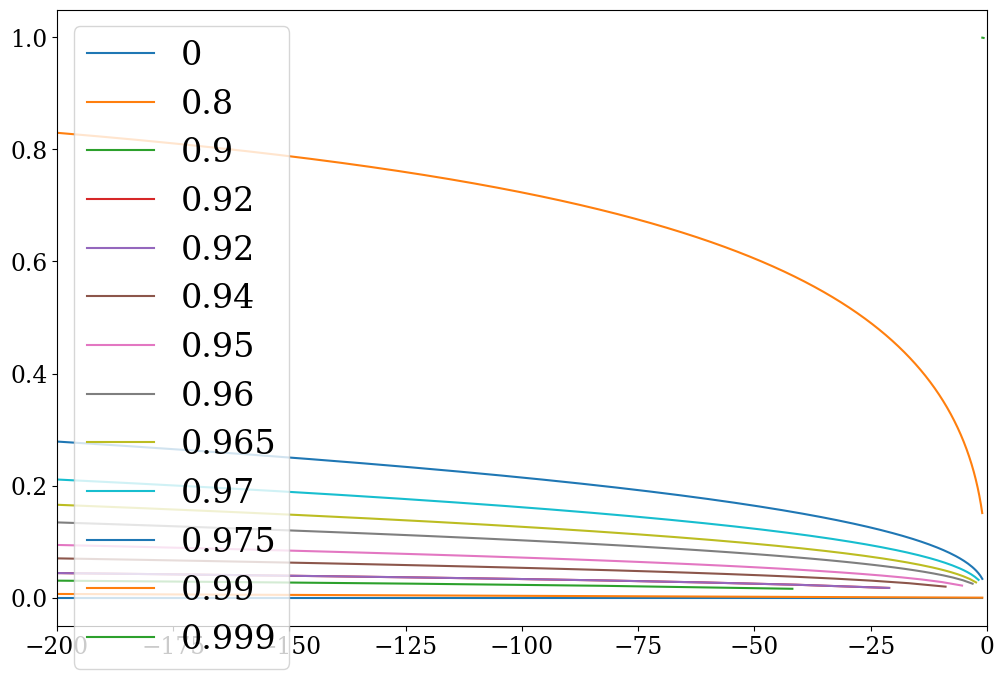

In [41]:
plt.figure()
merge_pad = 1*u.yr
m_1 = m_2 = 1e8*u.Msun
for ecc_i in [0,0.8,0.9,0.92,0.92,0.94,0.95,0.96,0.965,0.97,0.975,0.99,0.999]:
    fgw = 1e-9*u.Hz
    forb0 = fgw/2
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=100000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label=str(ecc_i))
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,small_e_tol=0.05)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=100000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
        plt.plot(timesteps-t_merger,ecc,label=str(ecc_i))
# plt.yscale('log')
# plt.xlim(-15000,0)
plt.xlim(-200,0)
# plt.ylim(1e-8,1e-6)
plt.legend()
plt.show()

Okay. So the (rough) conclusion we can draw here is that for $m_1 = m_2 = 10^8 M_{\odot}$, the sweet spot for eccentricity that gives us a boost but has circularized by high-f is $e = 0.5 - 0.9$ while in the PTA band. Conversely, while lower eccentricities do not provide a significant frequency boost, such eccentricity would be present in the orphaned pulsar term signal even though the system would be fully circularized by time of merger. This would provide a unique and complementary probe of the system's dynamics which would be otherwise unobservable. Additionally, non-detection of orphan pulsar terms can provide robust upper limits on the eccentricity of lower-mass systems than we consider to be detectable in the analyses in this work.



Still not clear how we can actually run this for the grid under the constraints LEGWORK carries seeing as we really want to evolve backwards, not forwards. I think we take the above conclusions and punt the rest to future work.

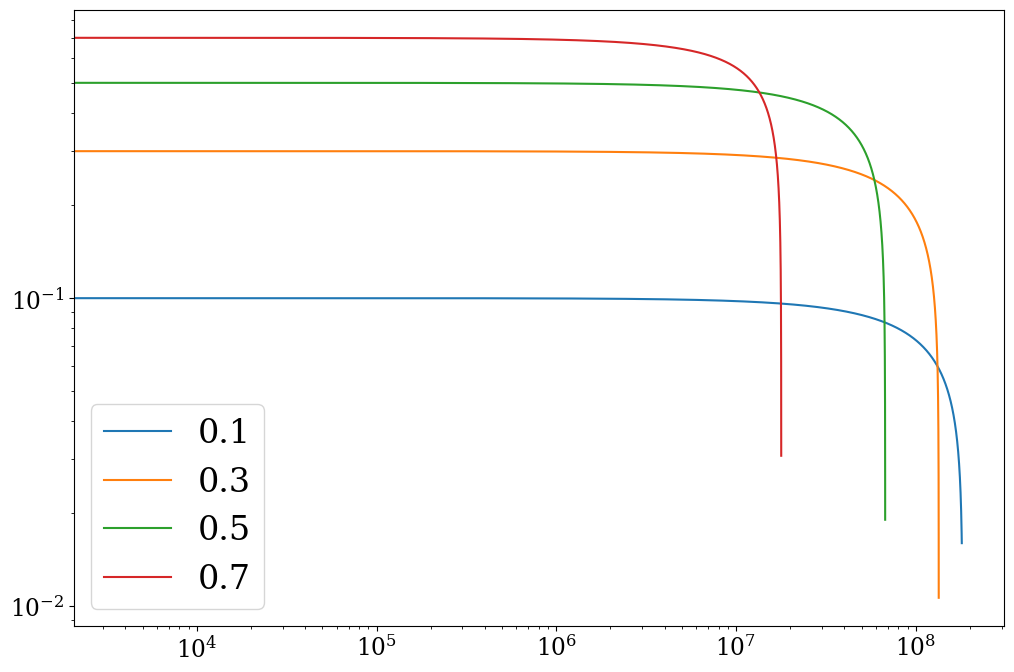

In [34]:
plt.figure()
merge_pad = 100*u.yr
for ecc_i in [0.1,0.3,0.5,0.7]:
    forb0 = 1e-9 * u.Hz
    t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True)
    timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=5000,
                                            t_evol=t_merger-merge_pad,t_before=merge_pad,
                                           output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
    plt.loglog(timesteps,ecc,label=str(ecc_i))
plt.legend()
plt.show()

In [35]:
binary = Binary(1e9*u.Msun,1e9*u.Msun,d_L=10*u.kpc) ## avoiding redshifting anything for now

In [36]:
binary.f_of_t(merge_pad)

<Quantity 1.07042704e-07 Hz>